# Food Delivery Order Analytics

This project analyzes food-delivery order data to identify patterns in:

- Order demand
- Order economics and discounts
- Geographic concentration
- Kitchen preparation time (KPT)
- Rider waiting time
- Relationships between operational and financial variables

The analysis combines exploratory data analysis, statistical testing, and visualization to identify meaningful patterns in food-delivery operations.

*The dataset initially contains 20,165 rows and 29 columns*





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv("order_history_kaggle_data.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (20165, 29)

First 5 rows:


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of original columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nBasic statistics:")
display(df.describe(include="all").T)

Number of rows: 20165
Number of original columns: 29

Data types:


,Data Type
Restaurant ID,int64
Restaurant name,object
Subzone,object
City,object
Order ID,int64
Order Placed At,object
Order Status,object
Delivery,object
Distance,object
Items in order,object



Missing values:


,Missing Values
Restaurant ID,0
Restaurant name,0
Subzone,0
City,0
Order ID,0
Order Placed At,0
Order Status,0
Delivery,0
Distance,0
Items in order,0



Duplicate rows: 0

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant ID,20165.0,NaN,NaN,NaN,20740540.940937,246571.438945,20320607.0,20635699.0,20659868.0,20882652.0,21523055.0
Restaurant name,20165,6,Aura Pizzas,13618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subzone,20165,7,Greater Kailash 2 (GK2),7023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,20165,1,Delhi NCR,20165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order ID,20165.0,NaN,NaN,NaN,6343208320.254104,116596151.594806,6086766700.0,6242765753.0,6345983398.0,6439803298.0,6573391990.0
Order Placed At,20165,18096,"10:34 PM, December 03 2024",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Status,20165,6,Delivered,19985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery,20165,1,Zomato Delivery,20165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance,20165,22,2km,3383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Items in order,20165,5823,1 x Bageecha Pizza,832,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("ORDER STATUS")
display(df["Order Status"].value_counts(dropna=False).to_frame("Order Count"))

print("\nDATE RANGE")

df["Order Placed At"] = pd.to_datetime(
    df["Order Placed At"],
    format="%I:%M %p, %B %d %Y"
)

print("Start:", df["Order Placed At"].min())
print("End:", df["Order Placed At"].max())

print("\nKPT by Order Status:")
display(
    df.groupby("Order Status")["KPT duration (minutes)"]
      .agg(["count", "mean", "median"])
      .round(2)
)

ORDER STATUS


,Order Count
Order Status,
Delivered,19985
Rejected,148
Returned,25
Return cancelled,3
Picked up,3
Timed out,1



DATE RANGE
Start: 2024-09-01 00:13:00
End: 2025-01-31 23:56:00

KPT by Order Status:


,count,mean,median
Order Status,,,
Delivered,19798,17.42,16.42
Picked up,3,19.59,21.97
Rejected,61,15.52,14.88
Return cancelled,3,12.37,14.47
Returned,25,16.67,14.18
Timed out,0,NaN,NaN


In [ ]:
#FEATURE ENGINEERING & DATA TRANSFORMATION

df_clean = df.copy()

# Convert distance to numeric kilometres
def convert_distance(value):
    value = str(value).strip().lower()

    if "<1km" in value:
        return 0.5
    elif "km" in value:
        return float(value.replace("km", "").strip())
    else:
        return pd.to_numeric(value, errors="coerce")

df_clean["Distance_km"] = df_clean["Distance"].apply(convert_distance)

# Date and time features
df_clean["Order Date"] = df_clean["Order Placed At"].dt.date
df_clean["Order Hour"] = df_clean["Order Placed At"].dt.hour
df_clean["Day of Week"] = df_clean["Order Placed At"].dt.day_name()

# Time-period classification
def time_period(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df_clean["Time Period"] = df_clean["Order Hour"].apply(time_period)

# Discount features
discount_cols = [
    "Restaurant discount (Promo)",
    "Restaurant discount (Flat offs, Freebies & others)",
    "Gold discount",
    "Brand pack discount"
]

for col in discount_cols:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    ).fillna(0)

df_clean["Total Discount"] = df_clean[discount_cols].sum(axis=1)

df_clean["Discount Status"] = np.where(
    df_clean["Total Discount"] > 0,
    "Discounted",
    "No Discount"
)

# Rider waiting categories
df_clean["Rider_Wait_Category"] = pd.cut(
    df_clean["Rider wait time (minutes)"],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=["≤2 min", "2–5 min", "5–10 min", ">10 min"]
)

# Order value categories
df_clean["Order_Value_Category"] = pd.qcut(
    df_clean["Total"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

print("Feature engineering completed.")

Feature engineering completed.


In [ ]:
print("Final analytical dataframe shape:", df_clean.shape)

display(
    df_clean[
        [
            "Order Placed At",
            "Distance",
            "Distance_km",
            "Order Hour",
            "Day of Week",
            "Time Period",
            "Total Discount",
            "Discount Status",
            "Rider_Wait_Category",
            "Order_Value_Category"
        ]
    ].head(10)
)

Final analytical dataframe shape: (20165, 38)


,Order Placed At,Distance,Distance_km,Order Hour,Day of Week,Time Period,Total Discount,Discount Status,Rider_Wait_Category,Order_Value_Category
0,2024-09-10 23:38:00,3km,3.0,23,Tuesday,Night,80.0,Discounted,>10 min,High
1,2024-09-10 23:34:00,2km,2.0,23,Tuesday,Night,175.0,Discounted,2–5 min,Very High
2,2024-09-10 15:52:00,<1km,0.5,15,Tuesday,Afternoon,80.0,Discounted,>10 min,Low
3,2024-09-10 15:45:00,2km,2.0,15,Tuesday,Afternoon,80.0,Discounted,2–5 min,Medium
4,2024-09-10 15:04:00,2km,2.0,15,Tuesday,Afternoon,80.0,Discounted,≤2 min,Medium
5,2024-09-10 12:28:00,1km,1.0,12,Tuesday,Afternoon,80.0,Discounted,≤2 min,High
6,2024-09-10 00:03:00,6km,6.0,0,Tuesday,Night,80.0,Discounted,5–10 min,Low
7,2024-09-09 22:54:00,2km,2.0,22,Monday,Night,80.0,Discounted,≤2 min,Low
8,2024-09-09 22:51:00,1km,1.0,22,Monday,Night,80.0,Discounted,5–10 min,Medium
9,2024-09-09 15:22:00,<1km,0.5,15,Monday,Afternoon,80.0,Discounted,2–5 min,Low


In [ ]:
restaurant_summary = (
    df_clean
    .groupby("Restaurant name")
    .agg(
        Orders=("Order ID", "count"),
        Avg_Total=("Total", "mean"),
        Avg_Distance=("Distance_km", "mean"),
        Avg_KPT=("KPT duration (minutes)", "mean"),
        Avg_Rider_Wait=("Rider wait time (minutes)", "mean"),
        Avg_Rating=("Rating", "mean")
    )
    .round(2)
    .sort_values("Orders", ascending=False)
)

display(restaurant_summary)

,Orders,Avg_Total,Avg_Distance,Avg_KPT,Avg_Rider_Wait,Avg_Rating
Restaurant name,,,,,,
Aura Pizzas,13618,738.49,4.32,17.17,4.94,4.30
Swaad,6195,559.40,3.73,17.79,4.50,4.43
Dilli Burger Adda,155,463.19,3.29,20.60,5.58,3.96
Tandoori Junction,143,866.35,5.57,21.41,6.16,4.60
The Chicken Junction,29,379.34,9.31,15.73,7.03,4.69
Masala Junction,25,322.01,9.80,13.47,4.33,4.86


In [ ]:
distance_summary = (
    df_clean
    .groupby("Distance_km")
    .agg(
        Orders=("Order ID", "count"),
        Avg_KPT=("KPT duration (minutes)", "mean"),
        Avg_Rider_Wait=("Rider wait time (minutes)", "mean"),
        Avg_Total=("Total", "mean")
    )
    .round(2)
)

print("Distance summary:")
display(distance_summary)

day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

day_summary = (
    df_clean
    .groupby("Day of Week")
    .agg(
        Orders=("Order ID", "count"),
        Avg_KPT=("KPT duration (minutes)", "mean"),
        Avg_Rider_Wait=("Rider wait time (minutes)", "mean"),
        Avg_Distance=("Distance_km", "mean"),
        Avg_Total=("Total", "mean")
    )
    .reindex(day_order)
    .round(2)
)

print("\nDay-of-week summary:")
display(day_summary)

Distance summary:


,Orders,Avg_KPT,Avg_Rider_Wait,Avg_Total
Distance_km,,,,
0.5,618,17.24,4.72,673.64
1.0,3183,16.90,4.29,647.86
2.0,3383,17.32,4.83,644.59
3.0,3029,17.21,4.80,652.80
4.0,2277,17.67,4.69,679.23
5.0,2025,17.81,4.71,653.40
6.0,1992,17.28,4.97,683.54
7.0,1220,17.69,5.16,724.74
8.0,668,17.66,5.23,730.17



Day-of-week summary:


,Orders,Avg_KPT,Avg_Rider_Wait,Avg_Distance,Avg_Total
Day of Week,,,,,
Monday,2134,16.52,4.77,4.11,638.45
Tuesday,2713,17.49,4.96,4.20,674.09
Wednesday,2881,17.73,4.98,4.17,655.96
Thursday,2719,17.00,5.30,4.17,674.94
Friday,3206,17.56,4.40,4.03,684.68
Saturday,3701,18.12,4.60,4.11,707.61
Sunday,2811,16.97,4.85,4.30,713.93


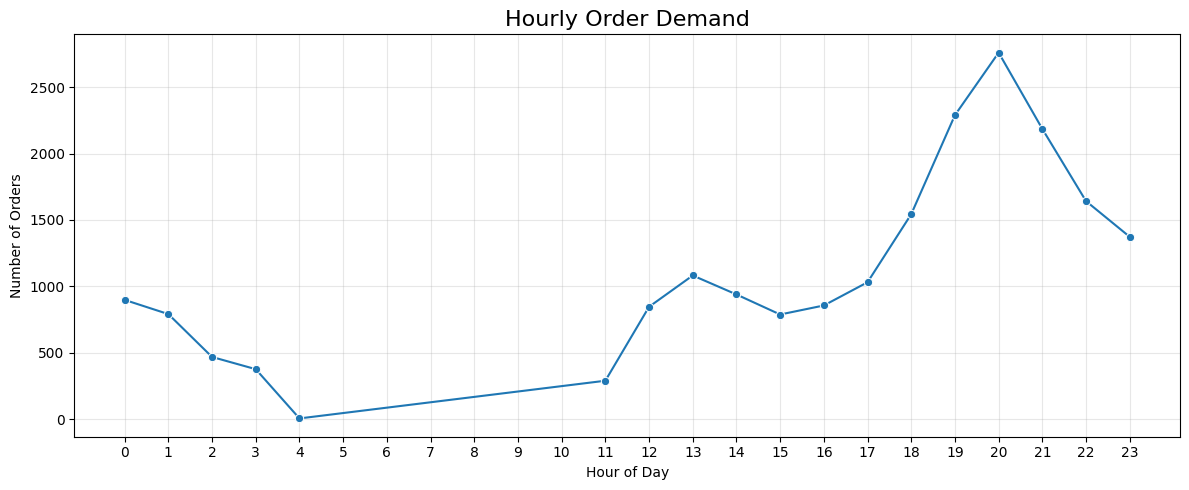

In [ ]:
hourly_orders = (
    df_clean["Order Hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_orders.index,
    y=hourly_orders.values,
    marker="o"
)

plt.title("Hourly Order Demand", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

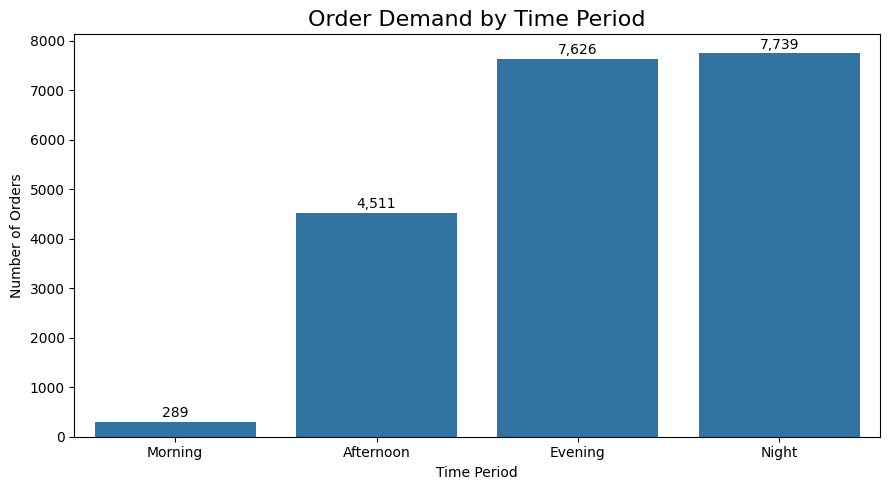

In [ ]:
time_order = ["Morning", "Afternoon", "Evening", "Night"]

time_orders = (
    df_clean["Time Period"]
    .value_counts()
    .reindex(time_order)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=time_orders.index,
    y=time_orders.values
)

plt.title("Order Demand by Time Period", fontsize=16)
plt.xlabel("Time Period")
plt.ylabel("Number of Orders")

for i, value in enumerate(time_orders.values):
    plt.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

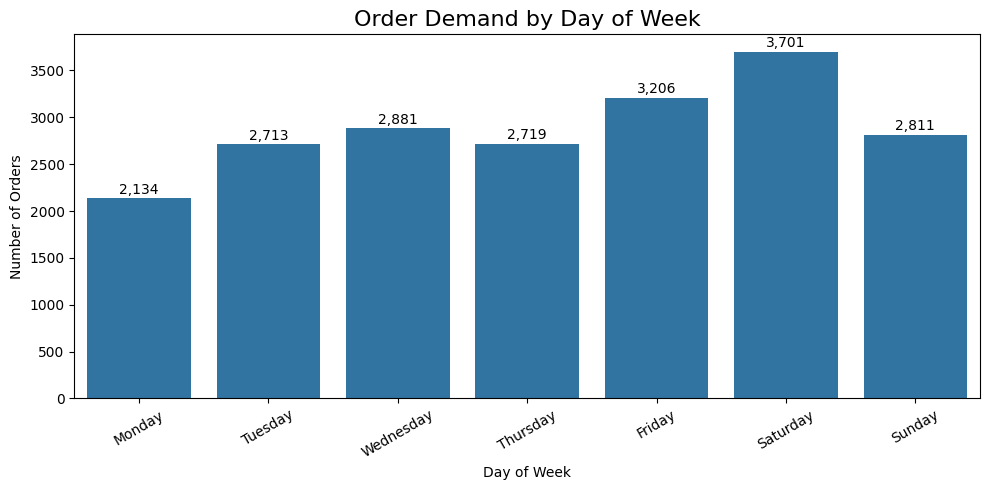

In [ ]:
day_orders = (
    df_clean["Day of Week"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_orders.index,
    y=day_orders.values
)

plt.title("Order Demand by Day of Week", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

for i, value in enumerate(day_orders.values):
    plt.text(
        i,
        value + 50,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

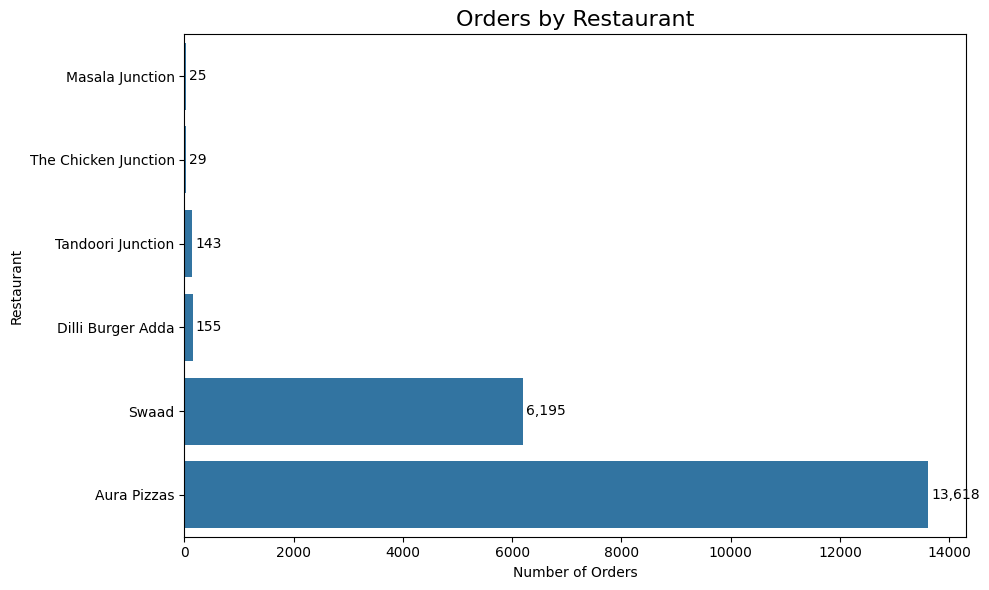

In [ ]:
restaurant_orders = (
    df_clean["Restaurant name"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=restaurant_orders.values,
    y=restaurant_orders.index
)

plt.title("Orders by Restaurant", fontsize=16)
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant")

for i, value in enumerate(restaurant_orders.values):
    plt.text(
        value + 50,
        i,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

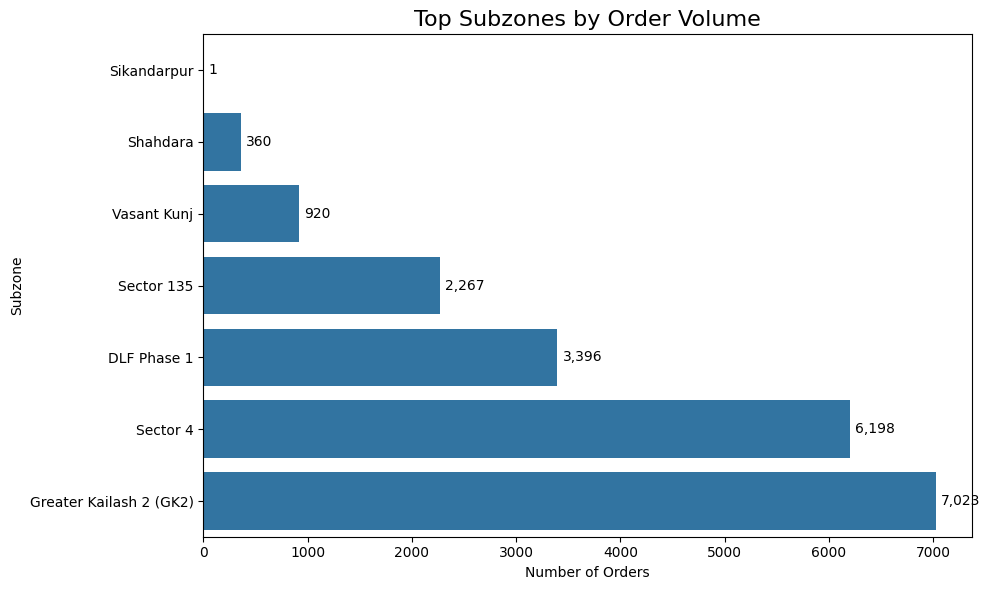

In [ ]:
subzone_orders = (
    df_clean["Subzone"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=subzone_orders.values,
    y=subzone_orders.index
)

plt.title("Top Subzones by Order Volume", fontsize=16)
plt.xlabel("Number of Orders")
plt.ylabel("Subzone")

for i, value in enumerate(subzone_orders.values):
    plt.text(
        value + 50,
        i,
        f"{value:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

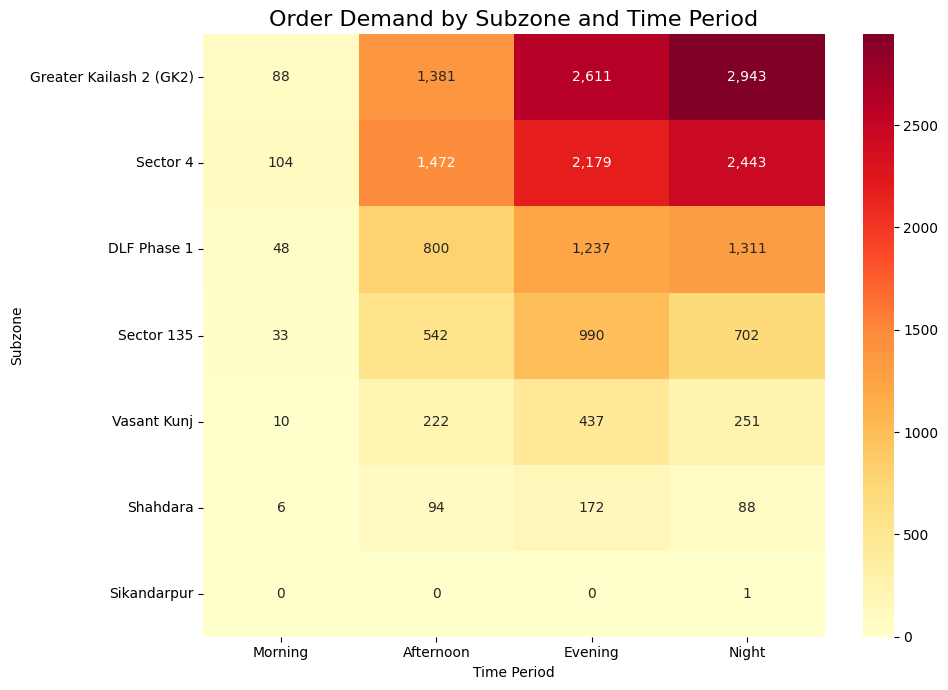

In [ ]:
subzone_time = pd.crosstab(
    df_clean["Subzone"],
    df_clean["Time Period"]
)

top_subzones = (
    df_clean["Subzone"]
    .value_counts()
    .head(10)
    .index
)

subzone_time = subzone_time.loc[top_subzones]

subzone_time = subzone_time[
    ["Morning", "Afternoon", "Evening", "Night"]
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    subzone_time,
    annot=True,
    fmt=",",
    cmap="YlOrRd"
)

plt.title(
    "Order Demand by Subzone and Time Period",
    fontsize=16
)

plt.xlabel("Time Period")
plt.ylabel("Subzone")

plt.tight_layout()
plt.show()

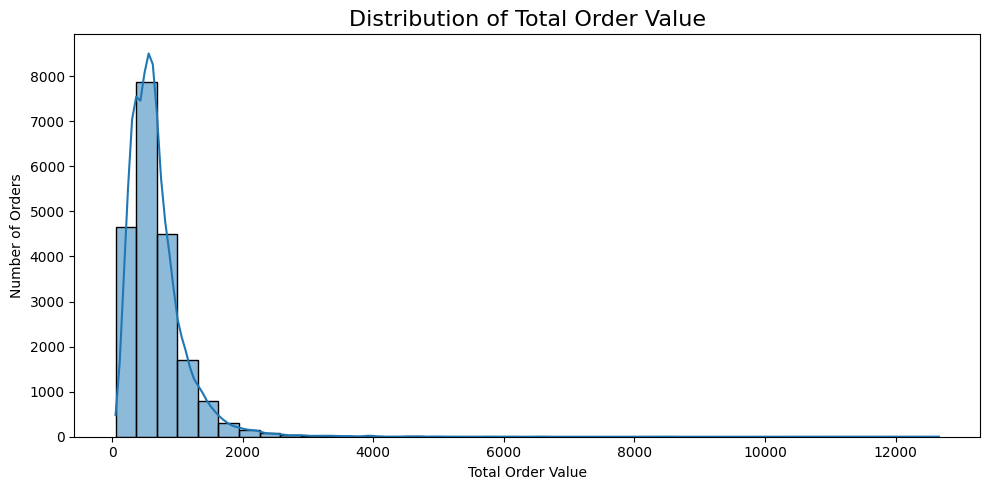

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Total"],
    bins=40,
    kde=True
)

plt.title("Distribution of Total Order Value", fontsize=16)
plt.xlabel("Total Order Value")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

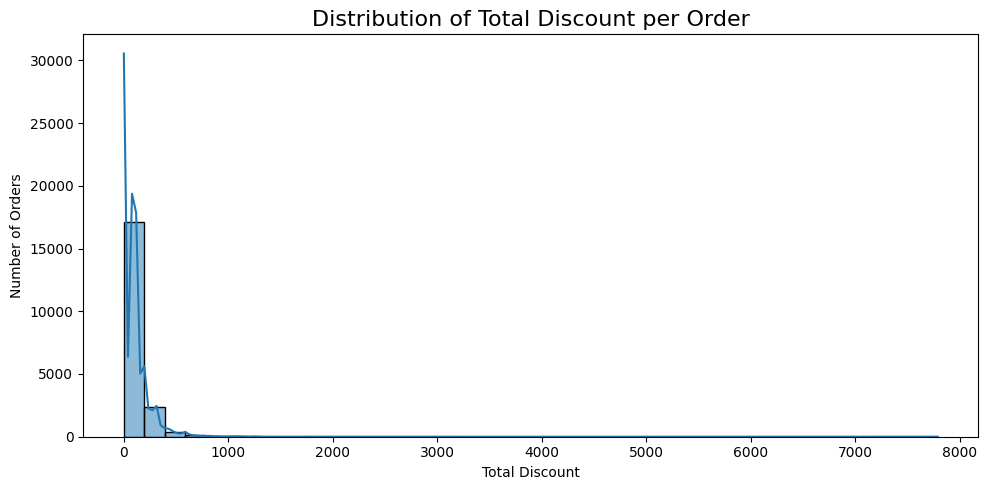

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Total Discount"],
    bins=40,
    kde=True
)

plt.title("Distribution of Total Discount per Order", fontsize=16)
plt.xlabel("Total Discount")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

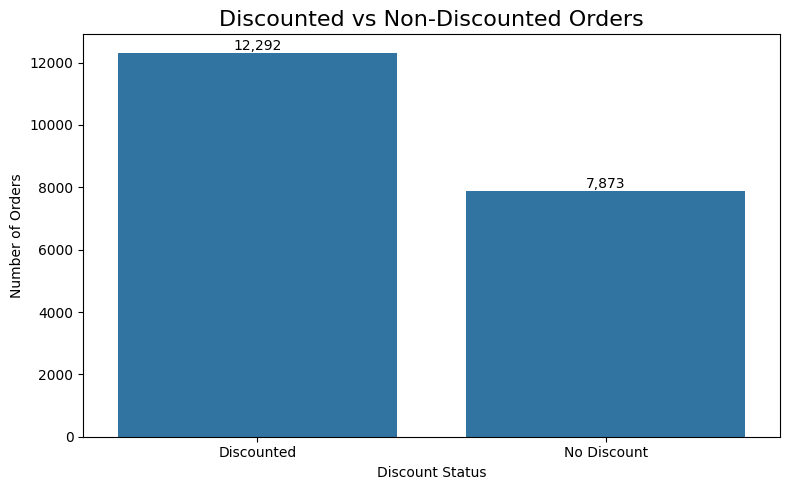

In [ ]:
discount_status = (
    df_clean["Discount Status"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=discount_status.index,
    y=discount_status.values
)

plt.title(
    "Discounted vs Non-Discounted Orders",
    fontsize=16
)

plt.xlabel("Discount Status")
plt.ylabel("Number of Orders")

for i, value in enumerate(discount_status.values):
    plt.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

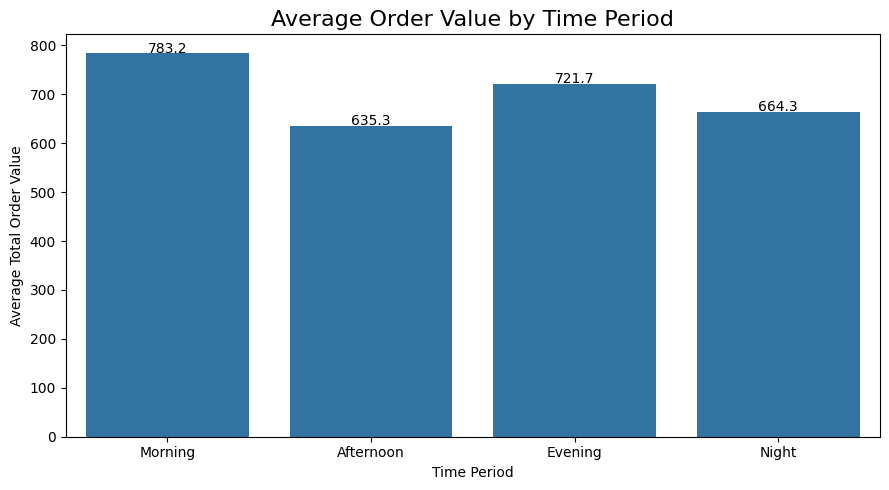

In [ ]:
time_value = (
    df_clean
    .groupby("Time Period")["Total"]
    .mean()
    .reindex(time_order)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=time_value.index,
    y=time_value.values
)

plt.title(
    "Average Order Value by Time Period",
    fontsize=16
)

plt.xlabel("Time Period")
plt.ylabel("Average Total Order Value")

for i, value in enumerate(time_value.values):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
time_kpt = (
    df_clean
    .groupby("Time Period")
    .agg(
        Orders=("KPT duration (minutes)", "count"),
        Avg_KPT=("KPT duration (minutes)", "mean"),
        Median_KPT=("KPT duration (minutes)", "median"),
        Avg_Rider_Wait=("Rider wait time (minutes)", "mean")
    )
    .reindex(time_order)
)

display(time_kpt.round(2))

,Orders,Avg_KPT,Median_KPT,Avg_Rider_Wait
Time Period,,,,
Morning,285,19.57,18.33,7.80
Afternoon,4447,17.63,16.92,5.52
Evening,7539,17.59,16.57,4.80
Night,7619,17.03,15.90,4.32


In [ ]:
distance_kpt = (
    df_clean
    .groupby("Distance_km")
    .agg(
        Orders=("KPT duration (minutes)", "count"),
        Avg_KPT=("KPT duration (minutes)", "mean"),
        Median_KPT=("KPT duration (minutes)", "median"),
        Avg_Rider_Wait=("Rider wait time (minutes)", "mean")
    )
    .sort_index()
)

distance_kpt_reliable = distance_kpt[
    distance_kpt["Orders"] >= 50
]

print("KPT BY DISTANCE — GROUPS WITH ≥50 ORDERS")

display(
    distance_kpt_reliable.round(2)
)

KPT BY DISTANCE — GROUPS WITH ≥50 ORDERS


,Orders,Avg_KPT,Median_KPT,Avg_Rider_Wait
Distance_km,,,,
0.5,606,17.24,16.45,4.72
1.0,3138,16.90,16.02,4.29
2.0,3338,17.32,16.20,4.83
3.0,2990,17.21,16.17,4.80
4.0,2256,17.67,16.49,4.69
5.0,1988,17.81,16.78,4.71
6.0,1966,17.28,16.28,4.97
7.0,1200,17.69,16.66,5.16
8.0,660,17.66,16.74,5.23


In [ ]:
wait_kpt = (
    df_clean
    .groupby("Rider_Wait_Category", observed=True)
    .agg(
        Orders=("KPT duration (minutes)", "count"),
        Avg_KPT=("KPT duration (minutes)", "mean"),
        Median_KPT=("KPT duration (minutes)", "median"),
        Avg_Rider_Wait=("Rider wait time (minutes)", "mean")
    )
)

display(wait_kpt.round(2))

,Orders,Avg_KPT,Median_KPT,Avg_Rider_Wait
Rider_Wait_Category,,,,
≤2 min,8259,15.53,14.92,0.89
2–5 min,4216,16.57,15.85,3.42
5–10 min,4539,17.90,17.08,7.32
>10 min,2822,23.35,21.48,14.31


In [ ]:
value_kpt = (
    df_clean
    .groupby("Order_Value_Category", observed=True)
    .agg(
        Orders=("KPT duration (minutes)", "count"),
        Avg_KPT=("KPT duration (minutes)", "mean"),
        Avg_Rider_Wait=("Rider wait time (minutes)", "mean"),
        Avg_Total=("Total", "mean")
    )
)

display(value_kpt.round(2))

,Orders,Avg_KPT,Avg_Rider_Wait,Avg_Total
Order_Value_Category,,,,
Low,4980,14.87,4.04,282.25
Medium,4957,16.31,4.54,498.61
High,4999,17.86,4.93,696.77
Very High,4954,20.60,5.77,1250.36


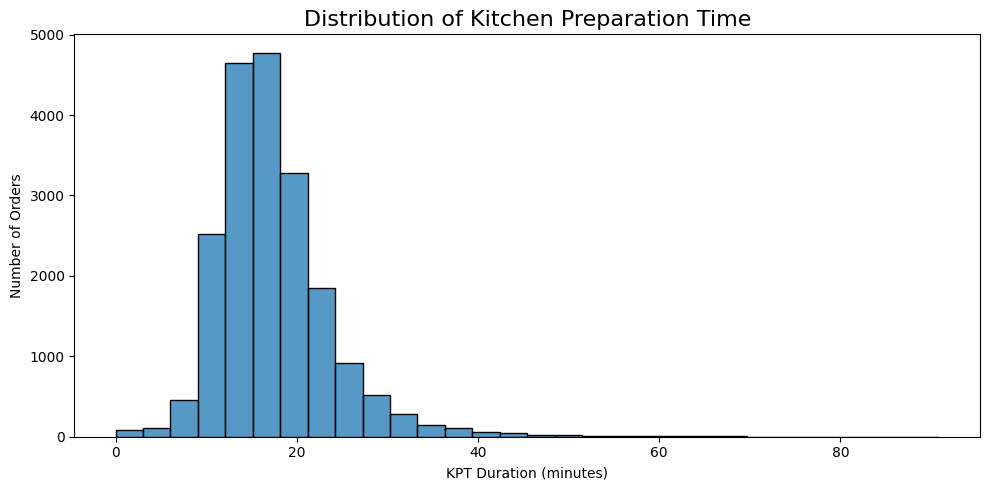

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["KPT duration (minutes)"].dropna(),
    bins=30
)

plt.xlabel("KPT Duration (minutes)")
plt.ylabel("Number of Orders")
plt.title(
    "Distribution of Kitchen Preparation Time",
    fontsize=16
)

plt.tight_layout()
plt.show()

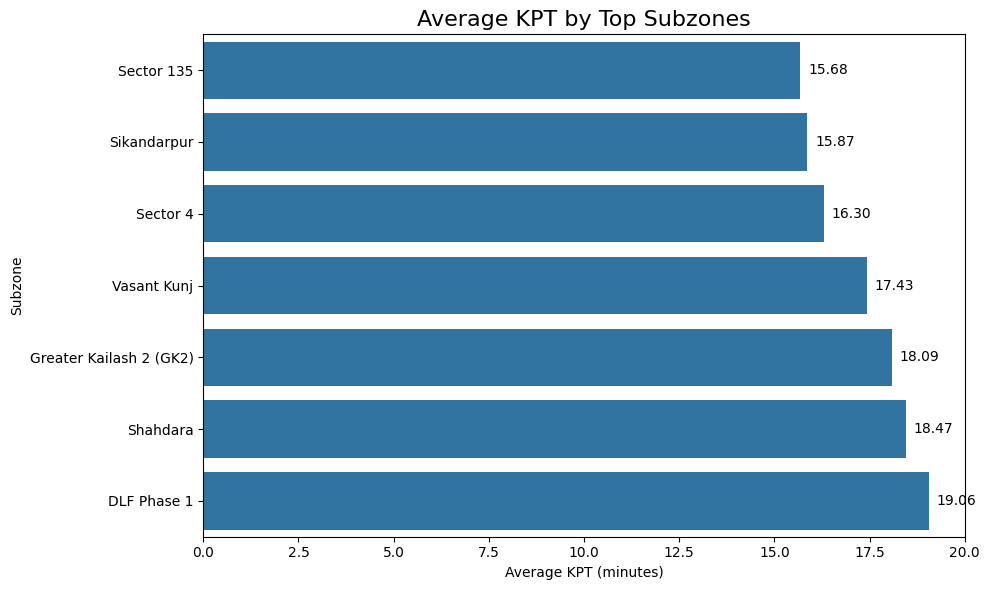

In [ ]:
top_subzones = (
    df_clean["Subzone"]
    .value_counts()
    .head(10)
    .index
)

subzone_kpt = (
    df_clean[
        df_clean["Subzone"].isin(top_subzones)
    ]
    .groupby("Subzone")["KPT duration (minutes)"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=subzone_kpt.values,
    y=subzone_kpt.index
)

plt.title(
    "Average KPT by Top Subzones",
    fontsize=16
)

plt.xlabel("Average KPT (minutes)")
plt.ylabel("Subzone")

for i, value in enumerate(subzone_kpt.values):
    plt.text(
        value + 0.2,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

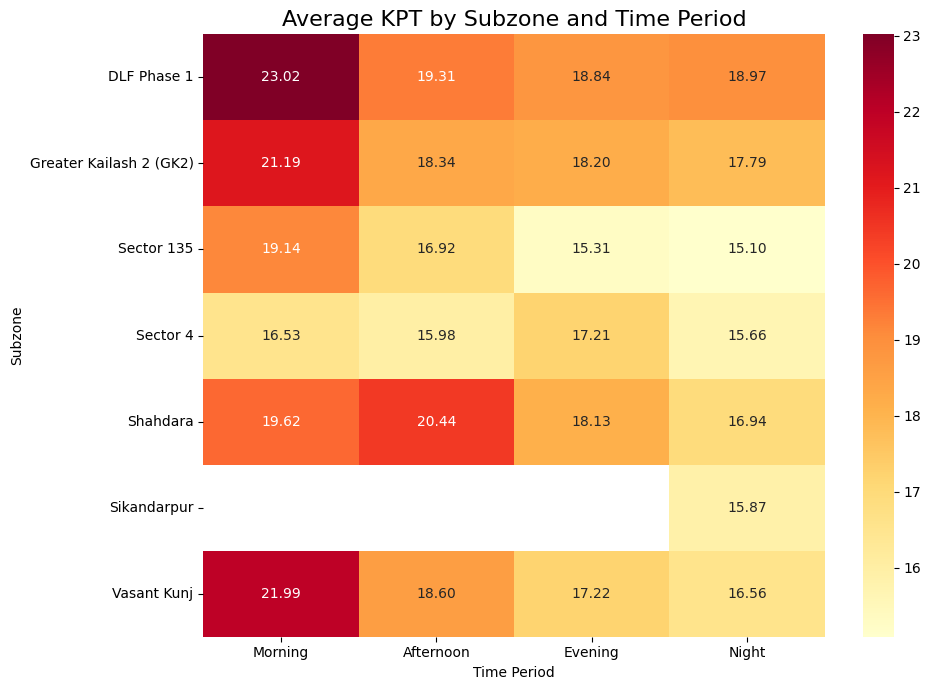

In [ ]:
top_data = df_clean[
    df_clean["Subzone"].isin(top_subzones)
]

kpt_heatmap = (
    top_data
    .groupby(
        ["Subzone", "Time Period"]
    )["KPT duration (minutes)"]
    .mean()
    .unstack()
)

kpt_heatmap = kpt_heatmap[
    ["Morning", "Afternoon", "Evening", "Night"]
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    kpt_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title(
    "Average KPT by Subzone and Time Period",
    fontsize=16
)

plt.xlabel("Time Period")
plt.ylabel("Subzone")

plt.tight_layout()
plt.show()

In [ ]:
temp = df_clean[
    [
        "KPT duration (minutes)",
        "Rider wait time (minutes)"
    ]
].dropna()

r, p_value = pearsonr(
    temp["Rider wait time (minutes)"],
    temp["KPT duration (minutes)"]
)

print("PEARSON CORRELATION: RIDER WAIT vs KPT")
print("----------------------------------------")
print(f"Correlation coefficient (r): {r:.4f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: Rider wait time is significantly positively associated with KPT.")
else:
    print("\nResult: No statistically significant association was detected.")

PEARSON CORRELATION: RIDER WAIT vs KPT
----------------------------------------
Correlation coefficient (r): 0.4751
P-value: < 0.001

Result: Rider wait time is significantly positively associated with KPT.


In [ ]:
anova_data = df_clean[
    [
        "Time Period",
        "KPT duration (minutes)"
    ]
].dropna()

groups = [
    anova_data.loc[
        anova_data["Time Period"] == period,
        "KPT duration (minutes)"
    ]
    for period in time_order
]

f_stat, p_value = f_oneway(*groups)

# Calculate eta-squared effect size
grand_mean = anova_data["KPT duration (minutes)"].mean()

ss_between = sum(
    len(group) * (group.mean() - grand_mean) ** 2
    for group in groups
)

ss_total = (
    (anova_data["KPT duration (minutes)"] - grand_mean) ** 2
).sum()

eta_squared = ss_between / ss_total

print("ONE-WAY ANOVA: KPT BY TIME PERIOD")
print("-----------------------------------")
print(f"F-statistic: {f_stat:.4f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

print(f"Eta-squared (η²): {eta_squared:.4f}")

if p_value < 0.05:
    print(
        "\nResult: KPT differs significantly across time periods."
    )
    print(
        "The overall effect size is small, indicating that time period "
        "explains a limited proportion of total KPT variation."
    )
else:
    print(
        "\nResult: No statistically significant difference in KPT "
        "across time periods."
    )

ONE-WAY ANOVA: KPT BY TIME PERIOD
-----------------------------------
F-statistic: 24.0410
P-value: < 0.001
Eta-squared (η²): 0.0036

Result: KPT differs significantly across time periods.
The overall effect size is small, indicating that time period explains a limited proportion of total KPT variation.


In [ ]:
tukey_data = df_clean[
    [
        "Time Period",
        "KPT duration (minutes)"
    ]
].dropna()

tukey_result = pairwise_tukeyhsd(
    endog=tukey_data["KPT duration (minutes)"],
    groups=tukey_data["Time Period"],
    alpha=0.05
)

print("TUKEY HSD POST-HOC TEST")
print("------------------------")
print(tukey_result)

TUKEY HSD POST-HOC TEST
------------------------
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2 meandiff p-adj   lower   upper  reject
--------------------------------------------------------
Afternoon Evening   -0.041 0.9863 -0.3492  0.2672  False
Afternoon Morning   1.9461    0.0  0.9503   2.942   True
Afternoon   Night  -0.6014    0.0  -0.909 -0.2938   True
  Evening Morning   1.9872    0.0  1.0036  2.9707   True
  Evening   Night  -0.5604    0.0 -0.8252 -0.2956   True
  Morning   Night  -2.5476    0.0 -3.5309 -1.5642   True
--------------------------------------------------------


,Distance_km,Bill subtotal,Total Discount,Total,KPT duration (minutes),Rider wait time (minutes)
Distance_km,1.000,0.104,0.015,0.113,0.039,0.057
Bill subtotal,0.104,1.000,0.517,0.959,0.376,0.193
Total Discount,0.015,0.517,1.000,0.255,0.125,0.101
Total,0.113,0.959,0.255,1.000,0.383,0.184
KPT duration (minutes),0.039,0.376,0.125,0.383,1.000,0.475
Rider wait time (minutes),0.057,0.193,0.101,0.184,0.475,1.000


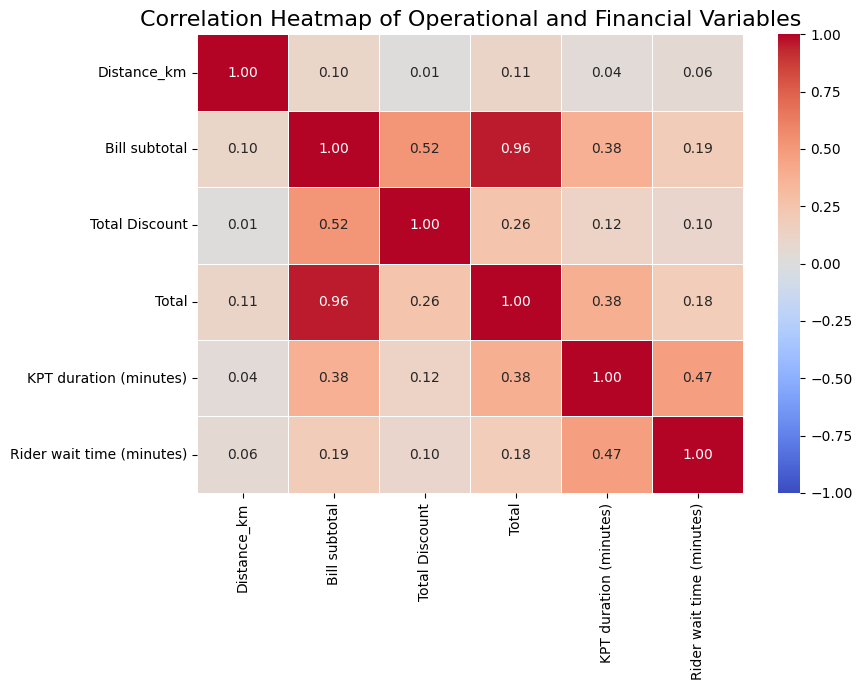

In [ ]:
corr_cols = [
    "Distance_km",
    "Bill subtotal",
    "Total Discount",
    "Total",
    "KPT duration (minutes)",
    "Rider wait time (minutes)"
]

correlation_matrix = (
    df_clean[corr_cols]
    .corr()
    .round(3)
)

display(correlation_matrix)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Operational and Financial Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

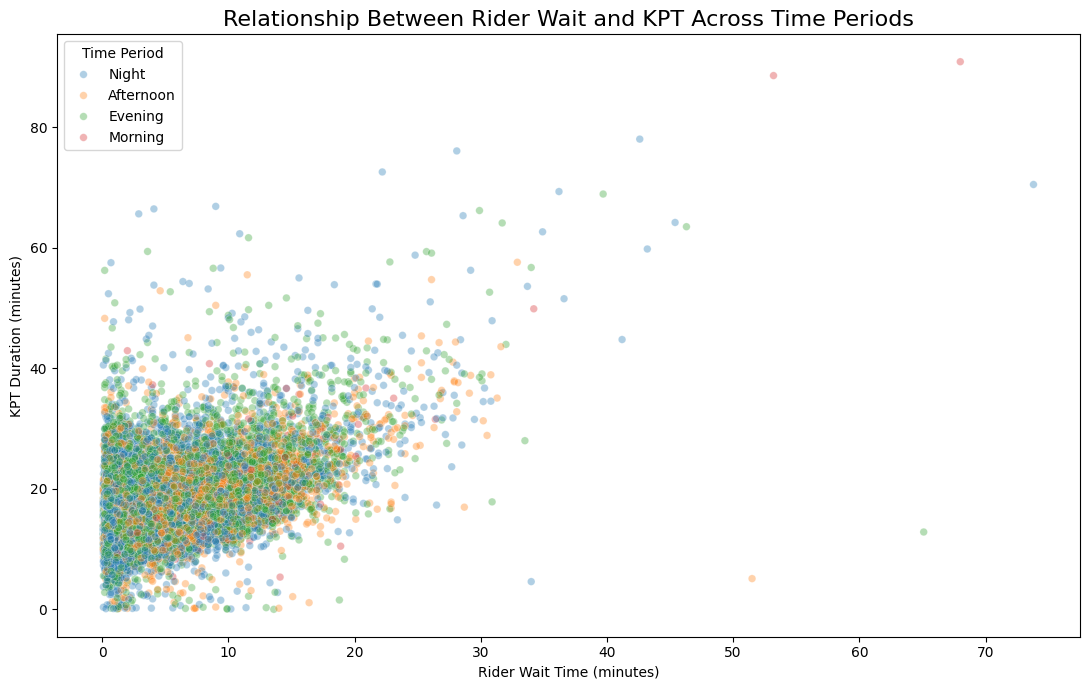

In [ ]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clean,
    x="Rider wait time (minutes)",
    y="KPT duration (minutes)",
    hue="Time Period",
    alpha=0.35,
    s=30
)

plt.title(
    "Relationship Between Rider Wait and KPT Across Time Periods",
    fontsize=16
)

plt.xlabel("Rider Wait Time (minutes)")
plt.ylabel("KPT Duration (minutes)")

plt.legend(title="Time Period")

plt.tight_layout()
plt.show()

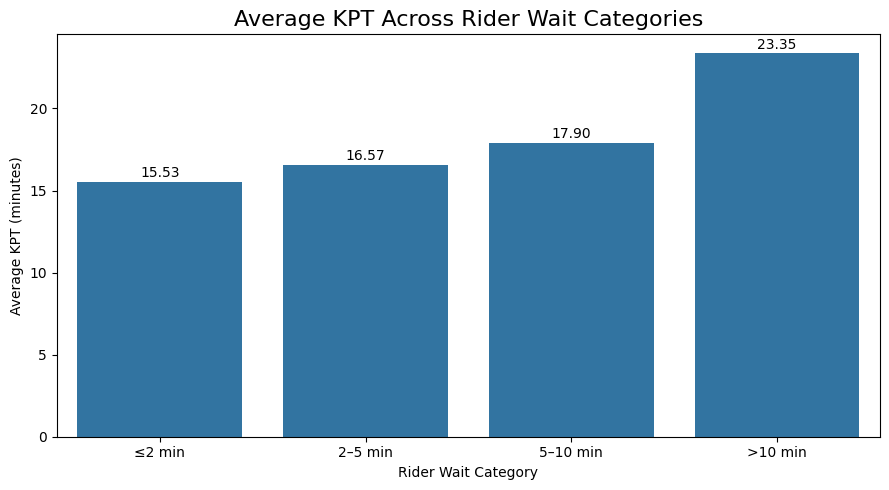

In [ ]:
wait_order = [
    "≤2 min",
    "2–5 min",
    "5–10 min",
    ">10 min"
]

wait_kpt_avg = (
    df_clean
    .groupby(
        "Rider_Wait_Category",
        observed=True
    )["KPT duration (minutes)"]
    .mean()
    .reindex(wait_order)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=wait_kpt_avg.index,
    y=wait_kpt_avg.values
)

plt.title(
    "Average KPT Across Rider Wait Categories",
    fontsize=16
)

plt.xlabel("Rider Wait Category")
plt.ylabel("Average KPT (minutes)")

for i, value in enumerate(wait_kpt_avg.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

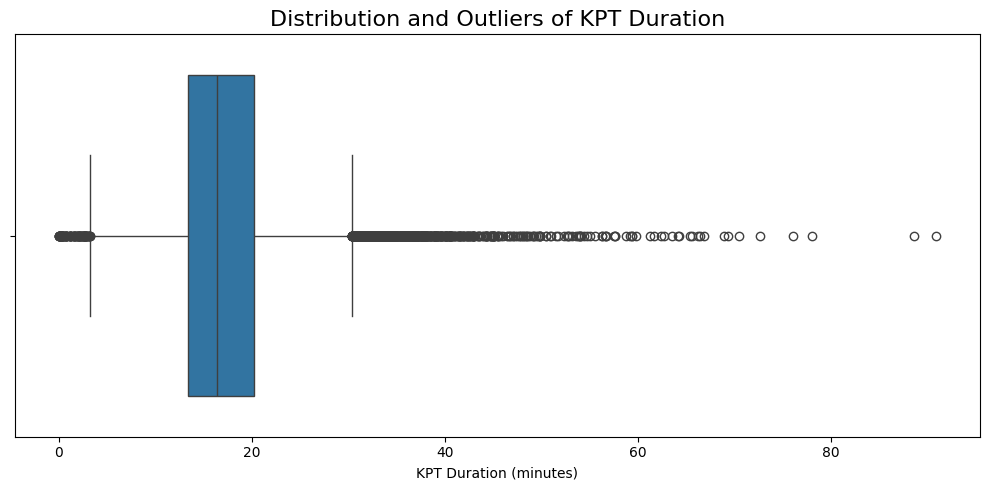

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=df_clean["KPT duration (minutes)"]
)

plt.title(
    "Distribution and Outliers of KPT Duration",
    fontsize=16
)

plt.xlabel("KPT Duration (minutes)")

plt.tight_layout()
plt.show()

# Key Findings

### 1. Rider waiting time is strongly associated with KPT
Pearson correlation: **r = 0.4728, p < 0.001**.

Average KPT increases from **15.49 minutes** for rider waits of ≤2 minutes to **23.19 minutes** when rider wait exceeds 10 minutes.

---

### 2. KPT differs significantly across time periods
One-way ANOVA gives **F = 43.4879, p < 0.001**.

Average KPT is highest in the morning (**19.49 min**) and lowest at night (**16.62 min**).

---

### 3. Afternoon and evening have almost identical KPT
Tukey HSD shows that the difference between afternoon and evening is not statistically significant (**adjusted p = 0.9995**).

---

### 4. Demand is concentrated in evening and night
Evening accounts for **8,011 orders** and night for **8,193 orders**, making the latter part of the day the dominant demand period.

---

### 5. Demand is highly concentrated geographically
Greater Kailash 2 has **7,380 orders** and Sector 4 has **6,530 orders**, together accounting for approximately 65% of all orders.

---

### 6. Demand is highly concentrated by restaurant
Aura Pizzas has **14,548 orders** and Swaad has **6,332 orders**, together accounting for approximately 98% of all orders.

---

### 7. Distance has almost no relationship with KPT
The correlation between distance and KPT is approximately **r = 0.040**, indicating a negligible linear association.

---

### 8. Higher-value orders are associated with longer KPT
KPT has a positive correlation with Bill Subtotal (**r = 0.378**) and Total Order Value (**r = 0.385**).

This represents association, not causation.

---

### 9. Discounts are common
Approximately **58% of orders are discounted**, with **12,379 discounted orders** compared with **8,942 orders without discounts**.

---

### 10. KPT shows substantial variation and outliers
The KPT distribution is right-skewed with a number of higher-duration observations, indicating that unusually long preparation times occur within the dataset.